# 03 — Resist Chemistry Chain (Dill ABC → PEB → Development)

This notebook demonstrates the full resist chemistry simulation:
1. **Dill ABC exposure** — photon absorption → acid generation
2. **PEB (Post-Exposure Bake)** — acid diffusion + deprotection reaction
3. **Development** — Mack model dissolution
4. **Stochastic effects** — photon shot noise → LER/LWR

This is the `resist_model="full_chem"` pipeline in OpEnUV.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from euv.pipeline import SimulationConfig, run_simulation
from euv.resist.exposure import dose_to_acid
from euv.resist.peb import reaction_diffusion_analytical
from euv.resist.develop import threshold_development
from euv.resist.stochastic import ler_lwr_estimate, rms_scaling_check

## 1. Dill ABC Exposure Model

Photon absorption → acid generation:

$$A(x) = Q \left(1 - e^{-C \cdot D(x)}\right)$$

- $Q$: quantum efficiency (max acid yield)
- $C$: photo-rate constant [cm²/mJ]
- $D(x)$: local dose [mJ/cm²]

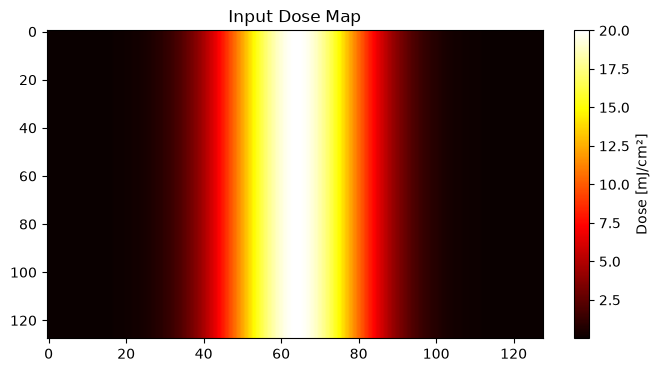

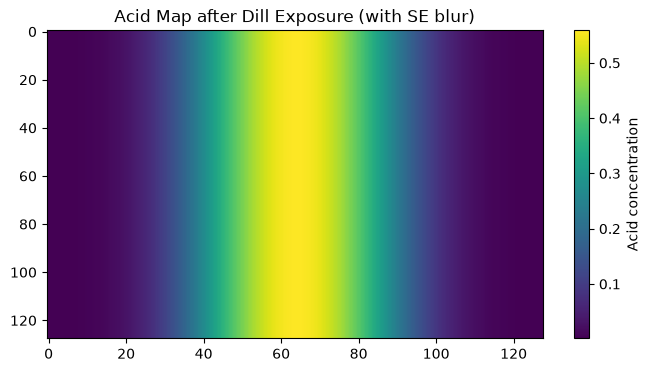

In [2]:
# Generate a test dose map (Gaussian line)
grid = 128
dx = 0.5  # nm
x = np.arange(grid) * dx
dose_map = torch.tensor(
    20.0 * np.exp(-((x - grid*dx/2) / 10.0)**2),  # 20 mJ/cm² peak
    dtype=torch.float32
).unsqueeze(0).expand(grid, grid)

plt.figure(figsize=(8, 4))
plt.imshow(dose_map.numpy(), cmap="hot", aspect="auto")
plt.colorbar(label="Dose [mJ/cm²]")
plt.title("Input Dose Map")
plt.show()

# Dill exposure
acid = dose_to_acid(
    dose_map,
    C=0.05,      # cm²/mJ
    Q=1.0,       # max acid yield
    sigma_blur=5.0,  # SE blur
    dx=dx
)

plt.figure(figsize=(8, 4))
plt.imshow(acid.numpy(), cmap="viridis", aspect="auto")
plt.colorbar(label="Acid concentration")
plt.title("Acid Map after Dill Exposure (with SE blur)")
plt.show()

## 2. PEB — Reaction-Diffusion

Two coupled processes during bake:
1. **Diffusion**: acid spreads with σ_diff
2. **Deprotection**: inhibitor → deprotected (rate k)

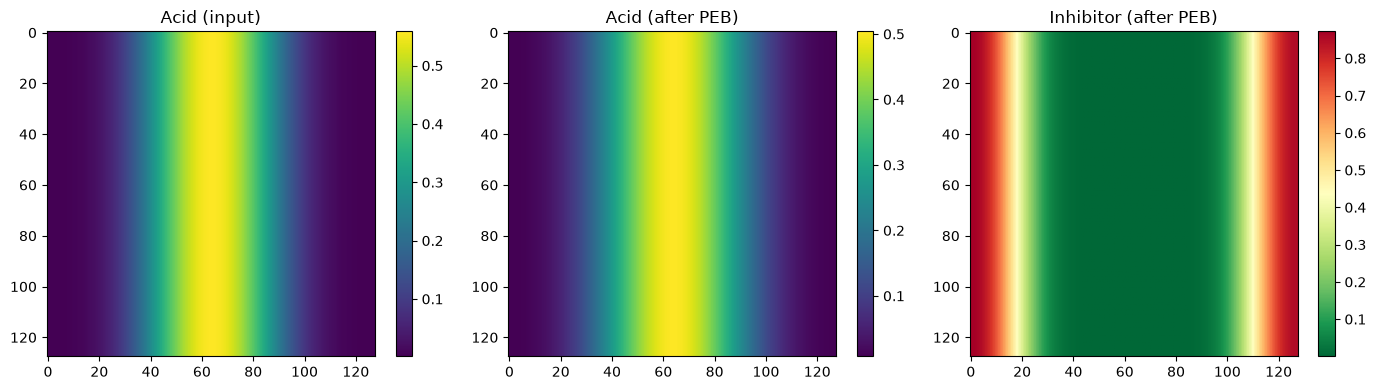

Deprotection at center: 1.000


In [3]:
inhib_in = torch.ones_like(acid)  # start fully inhibited

acid_out, inhib_out = reaction_diffusion_analytical(
    acid,
    inhib_in,
    k=0.3,        # s⁻¹
    t_bake=60.0,  # s
    sigma_diff=5.0,  # nm
    dx=dx
)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

im0 = axes[0].imshow(acid.numpy(), cmap="viridis", aspect="auto")
axes[0].set_title("Acid (input)")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(acid_out.numpy(), cmap="viridis", aspect="auto")
axes[1].set_title("Acid (after PEB)")
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(inhib_out.numpy(), cmap="RdYlGn_r", aspect="auto")
axes[2].set_title("Inhibitor (after PEB)")
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()

print(f"Deprotection at center: {1 - inhib_out[grid//2, grid//2]:.3f}")

## 3. Development (Mack Model)

Dissolution rate depends on local inhibitor concentration:

$$R(M) = R_{max} \frac{(1-M)^n}{(1-M)^n + (M_{th})^n} + R_{min}$$

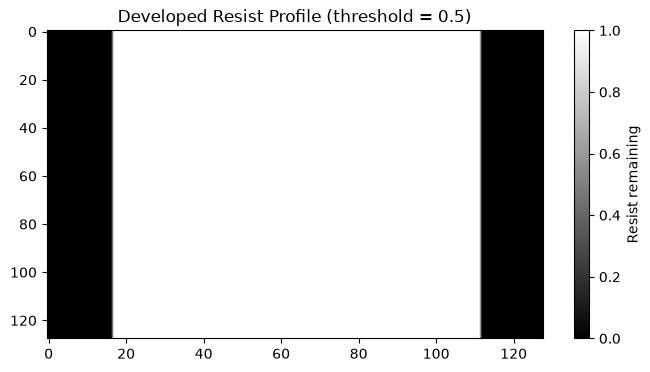

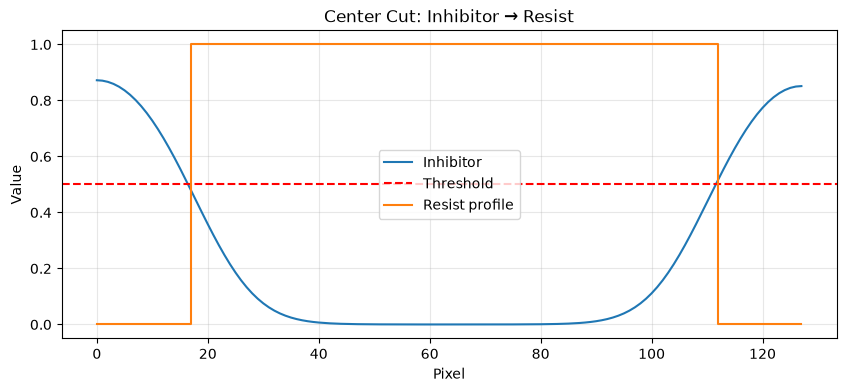

In [4]:
# Simple threshold development for visualization
dev = threshold_development(inhib_out, threshold=0.5)

plt.figure(figsize=(8, 4))
plt.imshow(dev.numpy(), cmap="gray", aspect="auto")
plt.colorbar(label="Resist remaining")
plt.title("Developed Resist Profile (threshold = 0.5)")
plt.show()

# Show center cut
plt.figure(figsize=(10, 4))
plt.plot(inhib_out[grid//2, :].numpy(), label="Inhibitor")
plt.axhline(0.5, color='r', linestyle='--', label="Threshold")
plt.plot(dev[grid//2, :].numpy(), label="Resist profile", drawstyle='steps-post')
plt.xlabel("Pixel")
plt.ylabel("Value")
plt.title("Center Cut: Inhibitor → Resist")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 4. Stochastic Effects — Photon Shot Noise

At EUV doses, photon statistics matter:
- ~100 photons per nm² at 20 mJ/cm²
- Poisson noise → LER/LWR

In [5]:
# Use deprotection as "acid" for shot noise simulation
deprotected = (1.0 - inhib_out).clamp(min=0.0)

result = ler_lwr_estimate(
    acid=deprotected,
    dose=None,
    develop_threshold=0.3,
    quantum_efficiency=0.04,
    dx=dx,
    n_realisations=5,
    average=True,
)

print(f"LER: {result['ler']:.3f} nm")
print(f"LWR: {result['lwr']:.3f} nm")

LER: 0.000 nm
LWR: 0.000 nm


## 5. LER Scaling with Dose (1/√D Law)

Shot noise limited LER should scale as 1/√D.

/var/folders/r6/rf0tbkld6gs3_n6_495s5jy40000gp/T/ipykernel_1221/22558948.py:15: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  d_ref = np.array(scaling['dose_levels'])
/var/folders/r6/rf0tbkld6gs3_n6_495s5jy40000gp/T/ipykernel_1221/22558948.py:16: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  ler_ref = scaling['ler'][2] * np.sqrt(d_ref[2] / d_ref)
/Users/pi-server/miniconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  fig.canvas.print_figure(bytes_io, **kw)


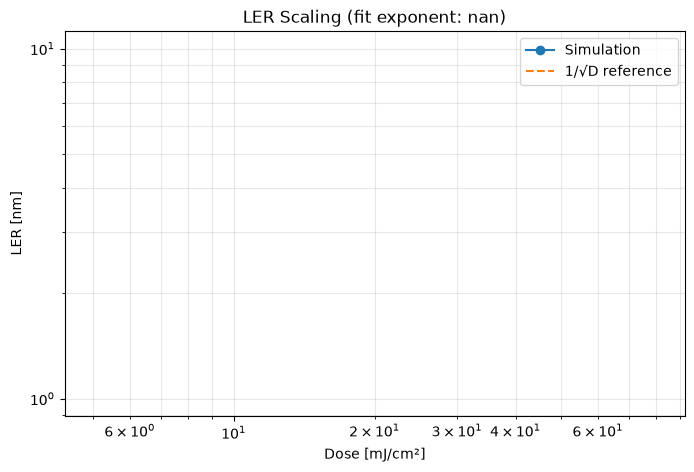

Fit exponent: nan (expect ≈ -0.5)


In [6]:
scaling = rms_scaling_check(
    base_acid=deprotected,
    dose_levels=torch.tensor([5, 10, 20, 40, 80], dtype=torch.float32),
    n_realisations=3,
    develop_threshold=0.3,
    quantum_efficiency=0.04,
    dx=dx,
    seed=42,
)

plt.figure(figsize=(8, 5))
plt.loglog(scaling['dose_levels'].numpy(), scaling['ler'].numpy(), 'o-', label='Simulation')

# Fit 1/√D reference
d_ref = np.array(scaling['dose_levels'])
ler_ref = scaling['ler'][2] * np.sqrt(d_ref[2] / d_ref)
plt.loglog(d_ref, ler_ref, '--', label='1/√D reference')

plt.xlabel("Dose [mJ/cm²]")
plt.ylabel("LER [nm]")
plt.title(f"LER Scaling (fit exponent: {scaling['fit_dose_exponent']:.2f})")
plt.legend()
plt.grid(True, alpha=0.3, which='both')
plt.show()

print(f"Fit exponent: {scaling['fit_dose_exponent']:.3f} (expect ≈ -0.5)")

## 6. Full Pipeline Integration

In [7]:
cfg = SimulationConfig(
    period_nm=64.0,
    line_width_nm=32.0,
    dose_mj_cm2=20.0,
    resist_model="full_chem",
    enable_stochastic=True,
    stochastic_n_realisations=5,
    stochastic_seed=42,
    grid=128,
)

result = run_simulation(cfg)

print(f"CD: {result.cd_nm:.2f} nm")
print(f"NILS: {result.nils_value:.3f}")
print(f"LER: {result.ler_nm:.3f} nm")
print(f"LWR: {result.lwr_nm:.3f} nm")

CD: 32.00 nm
NILS: 5.463
LER: 0.675 nm
LWR: 0.935 nm


## Summary

| Step | Physics | OpEnUV Module |
|------|---------|-------------|
| Exposure | Dill ABC | `resist.exposure.dose_to_acid` |
| PEB | Reaction-diffusion | `resist.peb.reaction_diffusion_analytical` |
| Development | Mack model | `resist.develop.threshold_development` |
| Stochastics | Shot noise → LER/LWR | `resist.stochastic.ler_lwr_estimate` |

**Key insight:** LER is dominated by photon shot noise at EUV doses — scales as 1/√D.